
========== HEAD ==========

   CustomerID  Recency  Frequency  MonetaryTotal  MonetaryAvg  MonetaryStd  \
0       17850      302         35        5288.63    16.950737    13.603662   
1       13047       32         18        3079.10    15.709694    11.684769   
2       12583        3         18        7187.34    28.634821    23.150132   
3       13748       96          5         948.25    33.866071    42.953119   
4       15100      330          6         635.10   105.850000   215.986263   

   MonetaryMin  MonetaryMax  TotalQuantity  AvgQuantityPerTransaction  ...  \
0       -30.60       107.25           1693                   5.426282  ...   
1       -15.00        68.00           1355                   6.913265  ...   
2       -60.84       132.80           5009                  19.956175  ...   
3         9.36       204.00            439                  15.678571  ...   
4      -131.40       350.40             58                   9.666667  ...   

                Region  LoyaltyLe

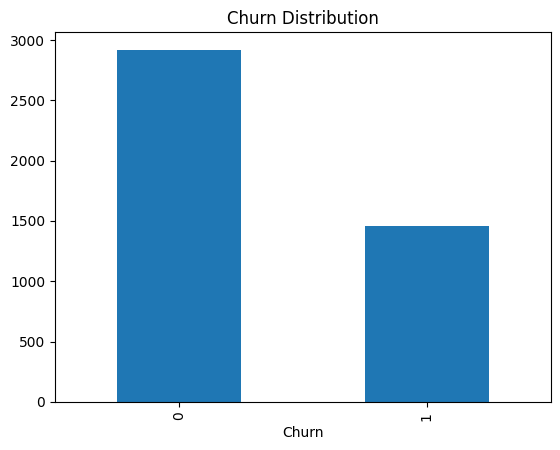

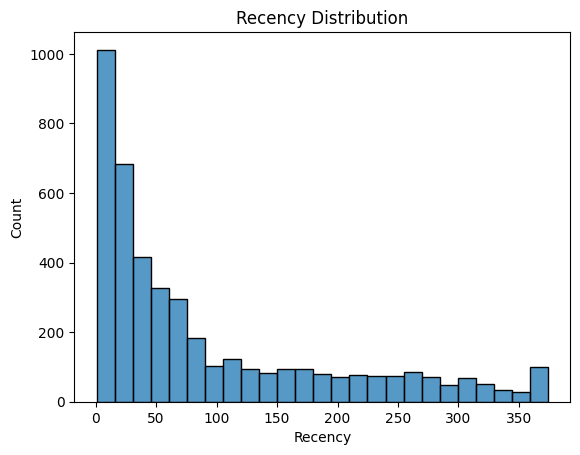

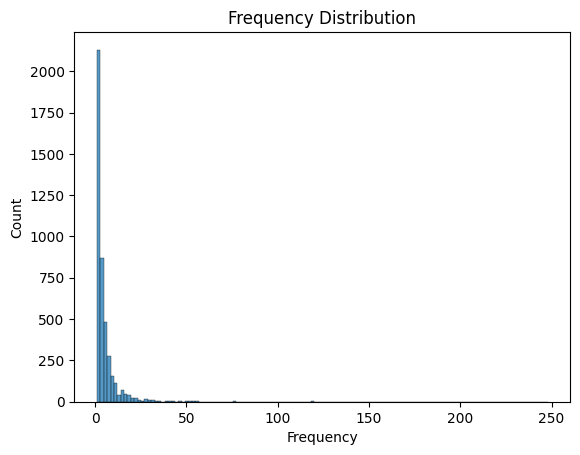

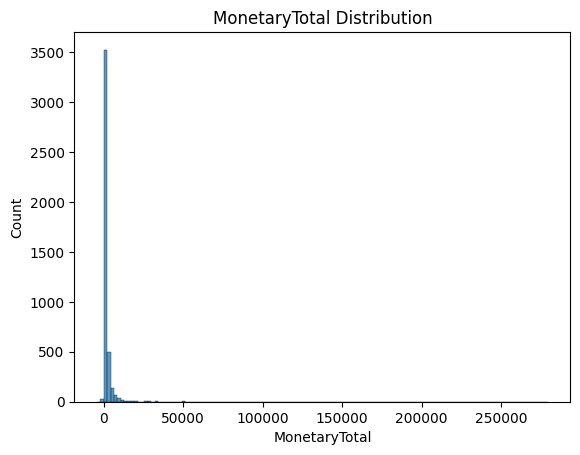

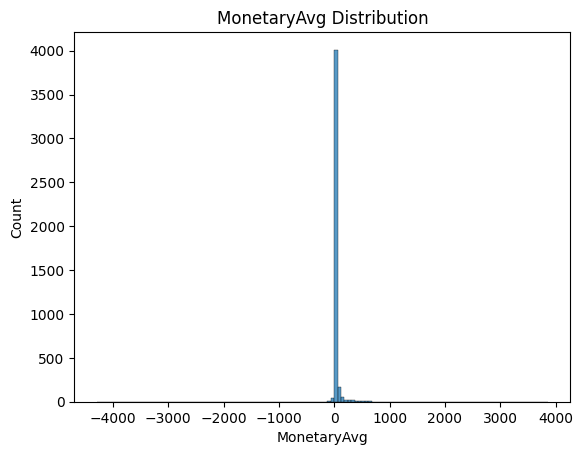

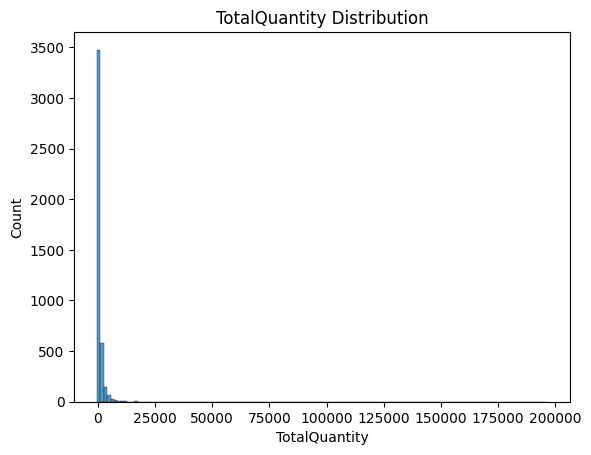

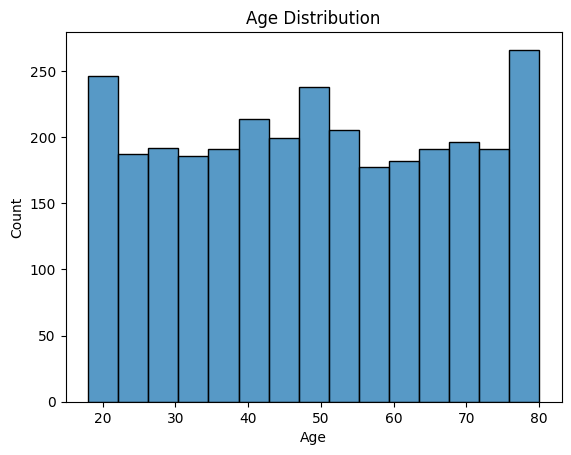

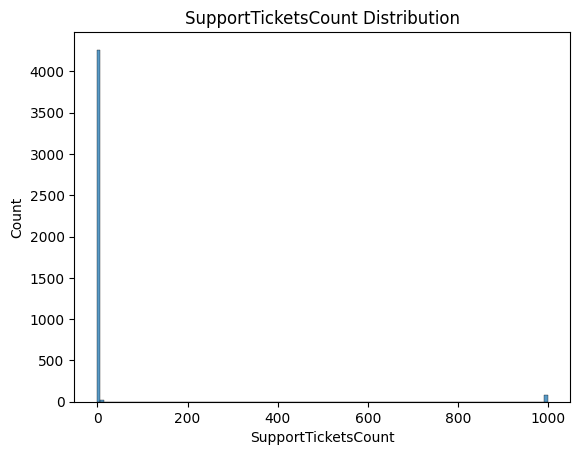

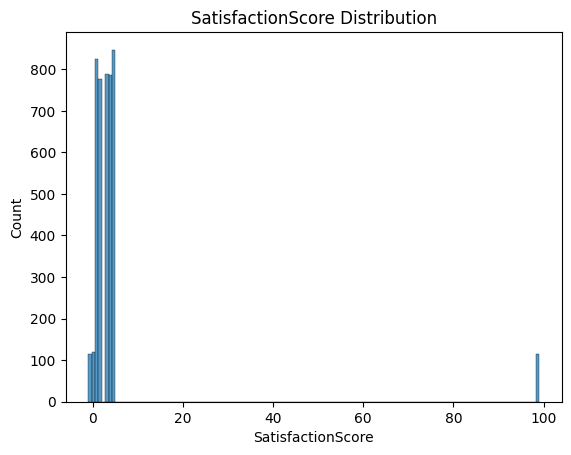

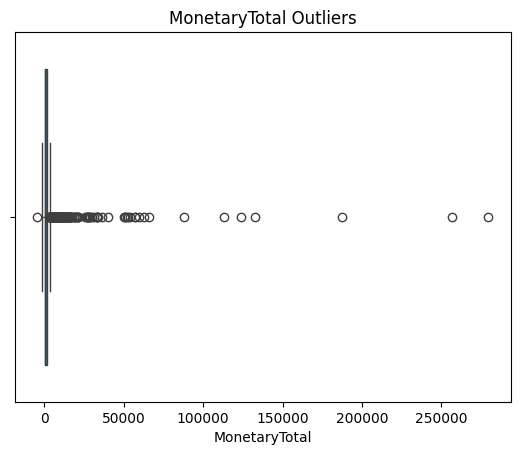

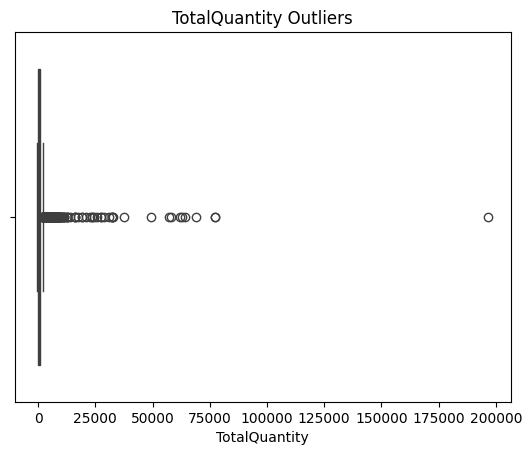

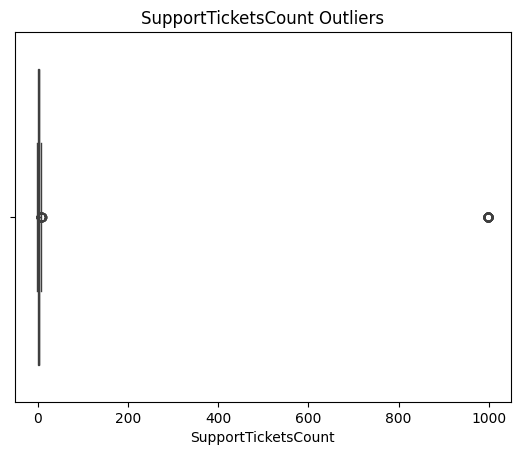

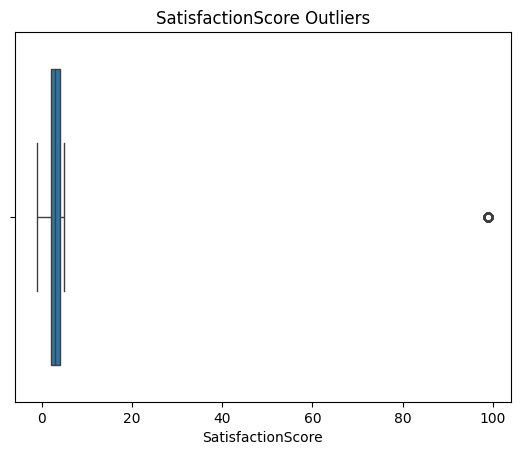

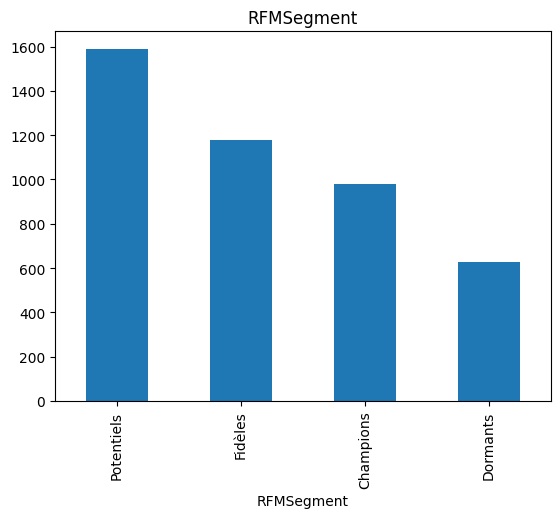

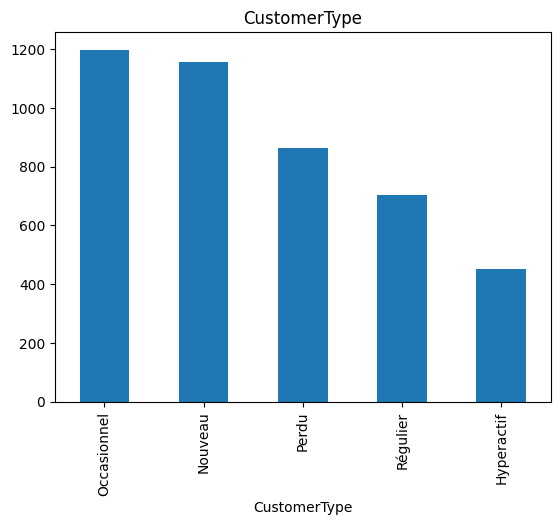

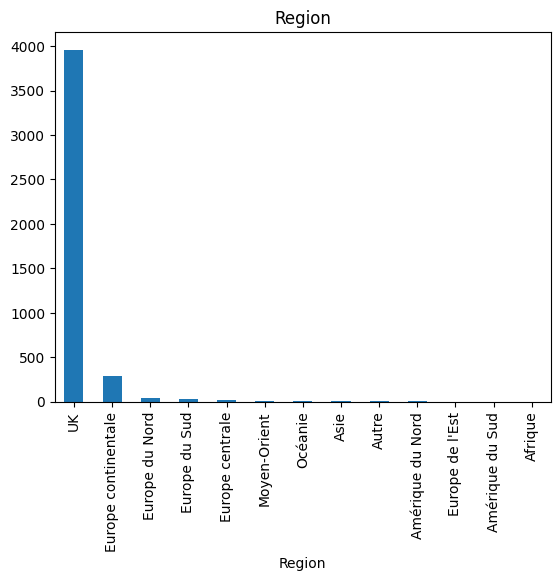

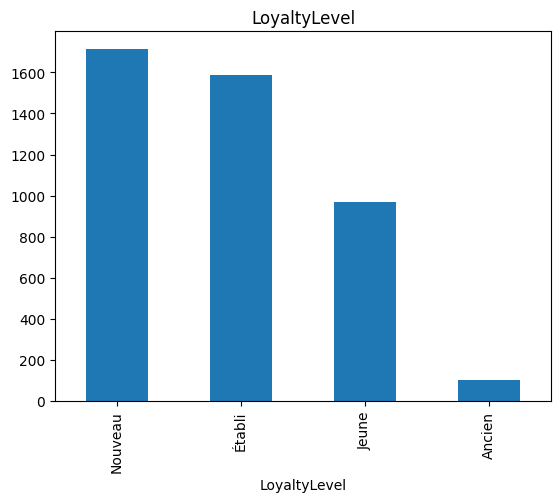

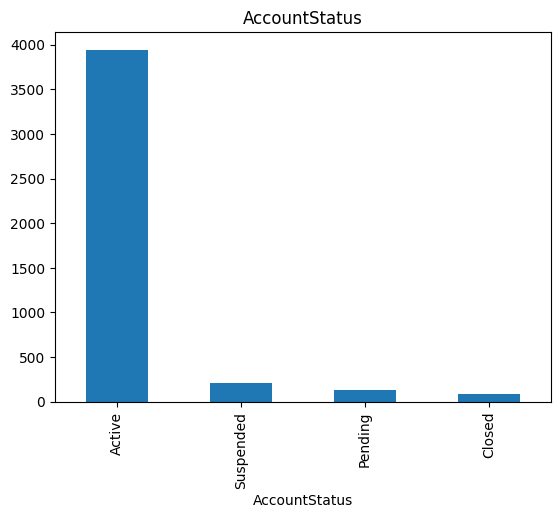

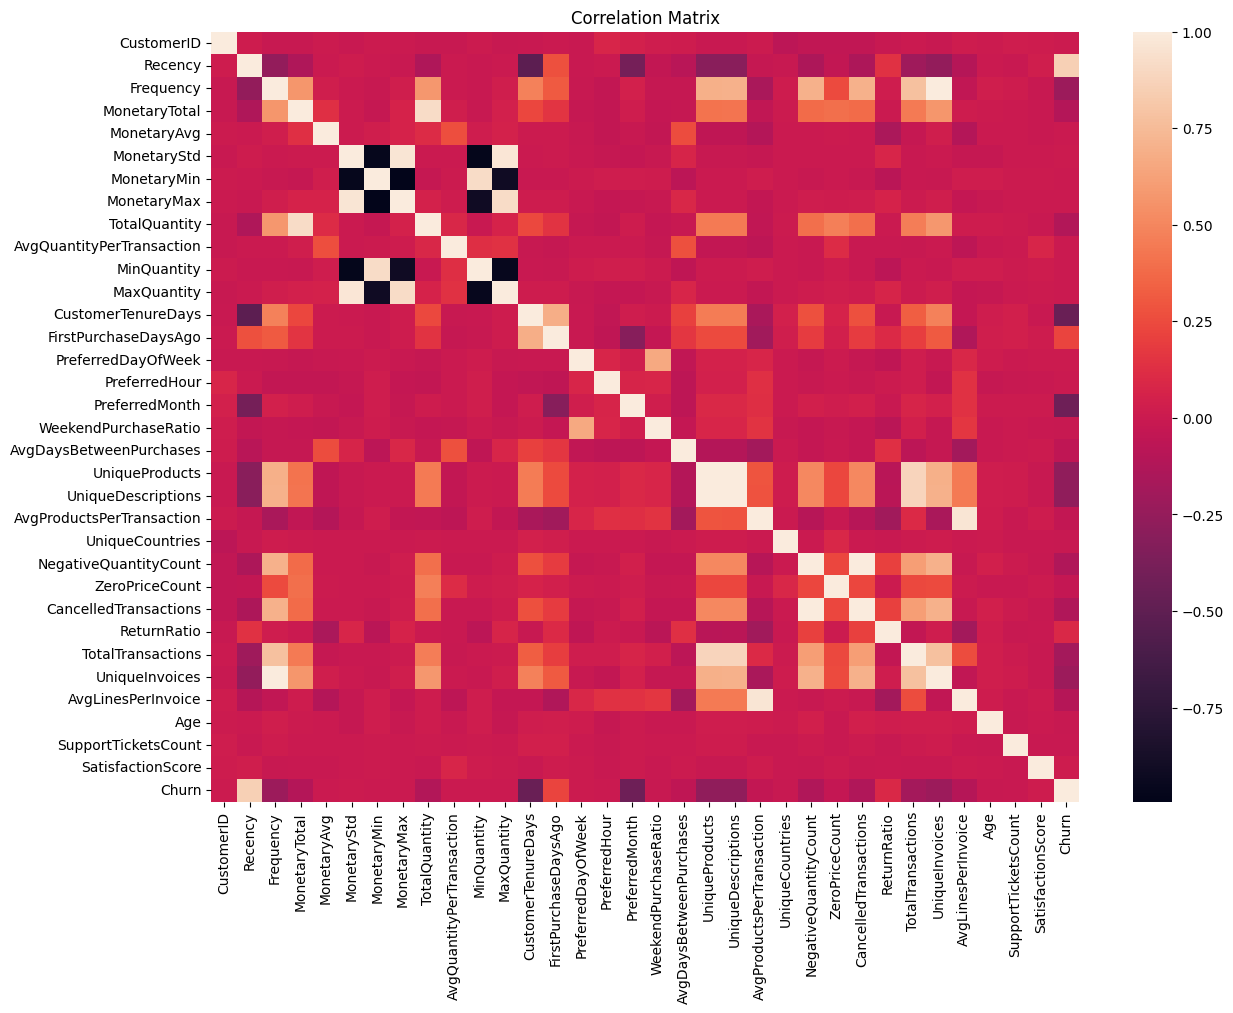

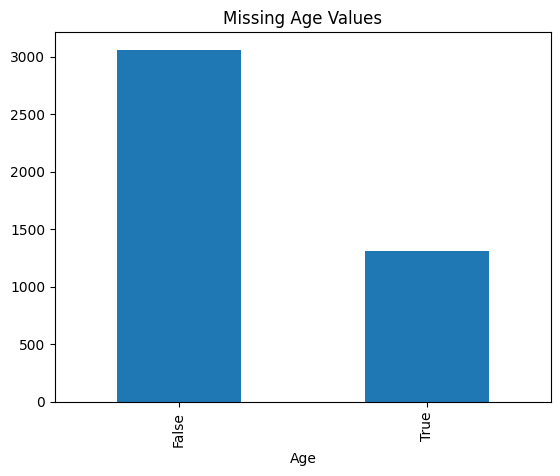

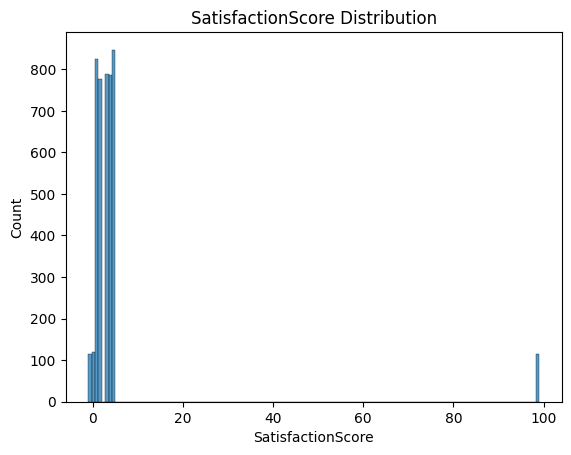

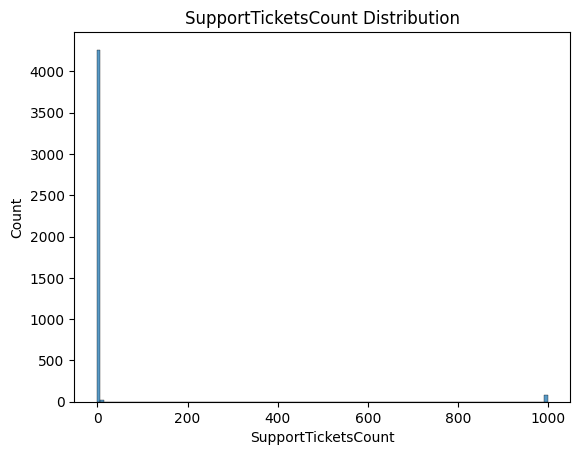

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv")


#################################################
# BASIC INFORMATION
#################################################

print("\n========== HEAD ==========\n")
print(df.head())

print("\n========== INFO ==========\n")
print(df.info())

print("\n========== DESCRIBE ==========\n")
print(df.describe())

print("\n========== MISSING VALUES ==========\n")
print(df.isnull().sum())


#################################################
# TARGET ANALYSIS
#################################################

print("\n========== CHURN DISTRIBUTION ==========\n")
print(df["Churn"].value_counts())

plt.figure()
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.show()


#################################################
# NUMERICAL DISTRIBUTIONS
#################################################

numeric_cols = [
    "Recency",
    "Frequency",
    "MonetaryTotal",
    "MonetaryAvg",
    "TotalQuantity",
    "Age",
    "SupportTicketsCount",
    "SatisfactionScore"
]

for col in numeric_cols:

    plt.figure()

    sns.histplot(df[col].dropna())

    plt.title(col + " Distribution")

    plt.show()


#################################################
# OUTLIERS
#################################################

outlier_cols = [
    "MonetaryTotal",
    "TotalQuantity",
    "SupportTicketsCount",
    "SatisfactionScore"
]

for col in outlier_cols:

    plt.figure()

    sns.boxplot(x=df[col])

    plt.title(col + " Outliers")

    plt.show()


#################################################
# CATEGORICAL FEATURES
#################################################

cat_cols = [
    "RFMSegment",
    "CustomerType",
    "Region",
    "LoyaltyLevel",
    "AccountStatus"
]

for col in cat_cols:

    plt.figure()

    df[col].value_counts().plot(kind="bar")

    plt.title(col)

    plt.show()


#################################################
# CORRELATION MATRIX
#################################################

plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr)

plt.title("Correlation Matrix")

plt.show()


#################################################
# SPECIAL FEATURES (IMPORTANT FOR PROJECT)
#################################################

# Age missing values visualization
plt.figure()

df["Age"].isnull().value_counts().plot(kind="bar")

plt.title("Missing Age Values")

plt.show()


# Satisfaction special values (-1 and 99)
plt.figure()

sns.histplot(df["SatisfactionScore"])

plt.title("SatisfactionScore Distribution")

plt.show()


# SupportTickets special values (-1 and 999)
plt.figure()

sns.histplot(df["SupportTicketsCount"])

plt.title("SupportTicketsCount Distribution")

plt.show()

In [2]:
print(df.columns.tolist())

['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'SupportTicketsCount', 'SatisfactionScore', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country', 'Churn']


                         MissingValues  PercentMissing
Age                               1311           29.99
AvgDaysBetweenPurchases             79            1.81


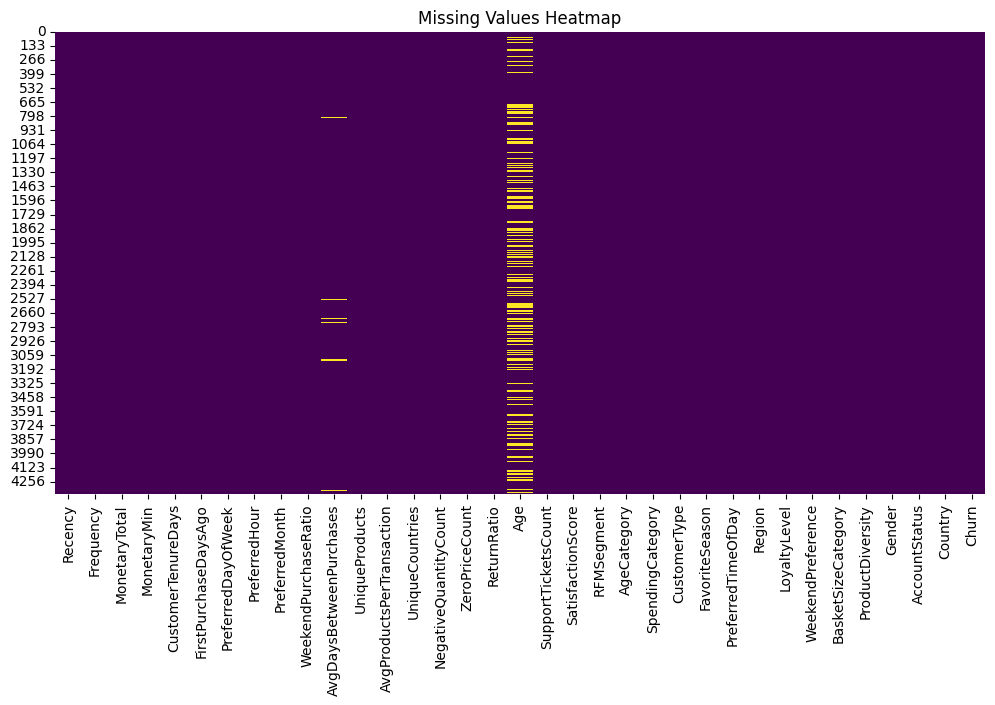

In [3]:
DROP_COLS = [
    "CustomerID", "MonetaryAvg", "MonetaryStd", "MonetaryMax",
    "TotalQuantity", "MinQuantity", "MaxQuantity", "AvgQuantityPerTransaction",
    "CancelledTransactions", "TotalTransactions",
    "UniqueDescriptions", "UniqueInvoices", "AvgLinesPerInvoice",
    "RegistrationDate", "NewsletterSubscribed", "LastLoginIP",
    "ChurnRiskCategory"
]

df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

# -------------------------------
# Visualize missing values
# -------------------------------
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "MissingValues": missing,
    "PercentMissing": missing_percent
})

print(missing_df[missing_df["MissingValues"] > 0])  # print only columns with missing values

# Heatmap visualization
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()